# Question 1

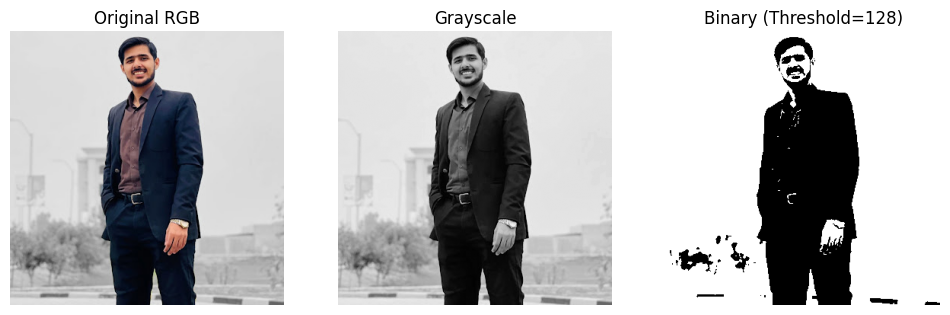

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('../assets/image.jpg')
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

R = rgb_image[:, :, 0]
G = rgb_image[:, :, 1]
B = rgb_image[:, :, 2]

gray_image = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

threshold = 128
binary_image = np.where(gray_image >= threshold, 255, 0).astype(np.uint8)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(rgb_image)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(binary_image, cmap='gray')
plt.title(f'Binary (Threshold={threshold})')
plt.axis('off')

plt.show()


## If we choose a different threshold for binary conversion:

Lower threshold (e.g., 50):
Many pixels will be greater than 50, so most of them will be converted to white (255).
→ The binary image will look brighter with larger white regions.

Higher threshold (e.g., 200):
Only very bright pixels will be above 200, so most pixels will become black (0).
→ The binary image will look darker with fewer white regions.

Why?
Because thresholding decides which pixels are kept as white vs. black. A lower threshold accepts more pixels as “bright enough,” while a higher threshold is stricter and only allows the brightest pixels to remain white.

# Question 2

C:\Users\muzam\AppData\Local\Temp\ipykernel_4484\400808162.py:30: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(2,4,5); plt.hist(gray_image.ravel(),256,[0,256]); plt.title('Original Histogram')
C:\Users\muzam\AppData\Local\Temp\ipykernel_4484\400808162.py:31: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(2,4,6); plt.hist(power_law_img.ravel(),256,[0,256]); plt.title('Power-law Histogram')
C:\Users\muzam\AppData\Local\Temp\ipykernel_4484\400808162.py:32: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(2,4,7); plt.hist(contrast_stretch.ravel(),256,[0,256]); plt.title('Contrast Stretch Histogram'

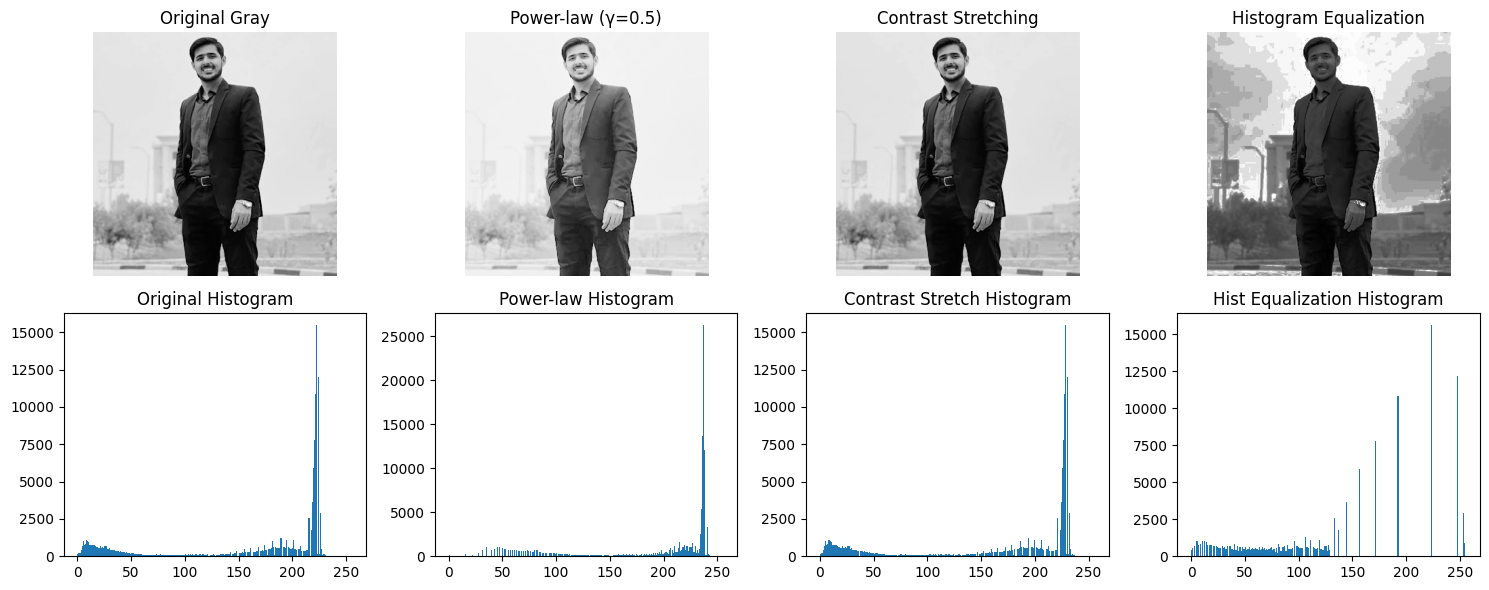

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('../assets/image.jpg')
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
R, G, B = rgb_image[:,:,0], rgb_image[:,:,1], rgb_image[:,:,2]
gray_image = (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)

gamma = 0.5
normalized = gray_image / 255.0
power_law = np.power(normalized, gamma)
power_law_img = np.uint8(power_law * 255)

min_val, max_val = np.min(gray_image), np.max(gray_image)
contrast_stretch = ((gray_image - min_val) / (max_val - min_val) * 255).astype(np.uint8)

hist, bins = np.histogram(gray_image.flatten(), 256, [0,256])
cdf = hist.cumsum()
cdf_normalized = cdf * 255 / cdf[-1]
hist_eq_img = np.interp(gray_image.flatten(), bins[:-1], cdf_normalized).reshape(gray_image.shape).astype(np.uint8)

plt.figure(figsize=(15,6))

plt.subplot(2,4,1); plt.imshow(gray_image, cmap='gray'); plt.title('Original Gray'); plt.axis('off')
plt.subplot(2,4,2); plt.imshow(power_law_img, cmap='gray'); plt.title('Power-law (γ=0.5)'); plt.axis('off')
plt.subplot(2,4,3); plt.imshow(contrast_stretch, cmap='gray'); plt.title('Contrast Stretching'); plt.axis('off')
plt.subplot(2,4,4); plt.imshow(hist_eq_img, cmap='gray'); plt.title('Histogram Equalization'); plt.axis('off')

plt.subplot(2,4,5); plt.hist(gray_image.ravel(),256,[0,256]); plt.title('Original Histogram')
plt.subplot(2,4,6); plt.hist(power_law_img.ravel(),256,[0,256]); plt.title('Power-law Histogram')
plt.subplot(2,4,7); plt.hist(contrast_stretch.ravel(),256,[0,256]); plt.title('Contrast Stretch Histogram')
plt.subplot(2,4,8); plt.hist(hist_eq_img.ravel(),256,[0,256]); plt.title('Hist Equalization Histogram')

plt.tight_layout()
plt.show()


## If γ < 1 in power-law transformation, what happens to dark pixels and why?

When γ < 1, dark pixels become brighter.

This happens because raising a small value (like 0.2) to a power less than 1 increases it (0.2^0.5 = 0.45).

As a result, the transformation stretches low-intensity values upward, brightening dark areas while keeping already bright regions almost unchanged.

## Contrast stretching and histogram equalization both improve contrast. How are they conceptually different?

Contrast Stretching:

A linear mapping of the current intensity range to the full [0, 255] range.

It only rescales based on min and max pixel values.

Example: If values are between 50–180, they are stretched to 0–255.

Histogram Equalization:

A non-linear mapping based on the image’s histogram.

Redistributes pixel intensities so the histogram becomes more uniform.

Enhances global contrast, especially when intensities are clustered in a narrow range.

# Question 3

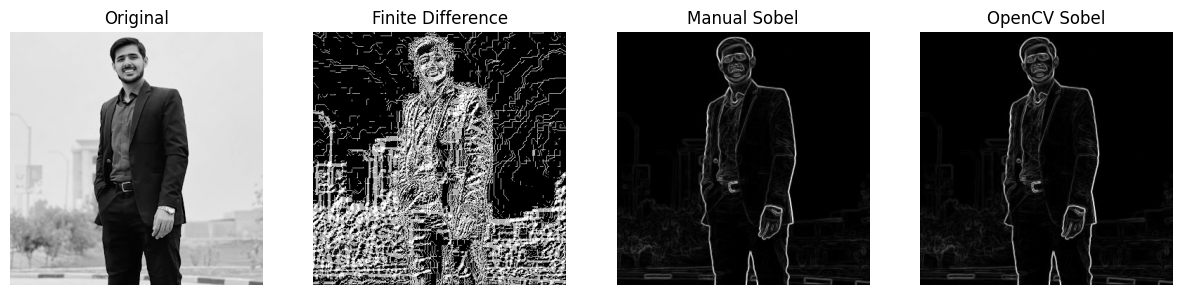

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('../assets/image.jpg', cv2.IMREAD_GRAYSCALE)

Gx = np.zeros_like(image, dtype=float)
Gy = np.zeros_like(image, dtype=float)

Gx[:, :-1] = image[:, 1:] - image[:, :-1]
Gy[:-1, :] = image[1:, :] - image[:-1, :]

gradient_magnitude = np.sqrt(Gx**2 + Gy**2)
edge_image = (gradient_magnitude / gradient_magnitude.max() * 255).astype(np.uint8)

sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude = np.sqrt(sobelx**2 + sobely**2)
sobel_edge = (sobel_magnitude / sobel_magnitude.max() * 255).astype(np.uint8)

opencv_sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0)
opencv_sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1)
opencv_sobel_mag = np.sqrt(opencv_sobelx**2 + opencv_sobely**2)
opencv_sobel_edge = (opencv_sobel_mag / opencv_sobel_mag.max() * 255).astype(np.uint8)

plt.figure(figsize=(15,5))
plt.subplot(1,4,1); plt.imshow(image, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(edge_image, cmap='gray'); plt.title('Finite Difference'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(sobel_edge, cmap='gray'); plt.title('Manual Sobel'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(opencv_sobel_edge, cmap='gray'); plt.title('OpenCV Sobel'); plt.axis('off')
plt.show()


## Q4: Why can noise produce false edges in gradient computation?

Noise introduces sudden pixel intensity changes.

Since gradients rely on differences between neighbors, noise creates sharp changes → interpreted as edges (false positives).

## Q5 Comparison: Finite Difference vs. Sobel for Edge Localization

The finite difference method simply subtracts adjacent pixel values. While this captures sudden changes in intensity, it is:

Very sensitive to noise (even small pixel fluctuations look like edges).

Provides edges that are thin but unstable.

The Sobel operator uses a 3×3 kernel with weighted coefficients. This has two important effects:

Smoothing effect: The averaging inside the kernel reduces the influence of noise.

Stronger response at real edges: Because it considers more neighboring pixels, it produces clearer and more continuous edge lines.

Therefore, Sobel localizes edges better than the simple finite difference because it balances derivative computation with local smoothing, giving more accurate and stable edges.

## Q6: Compare with OpenCV’s cv2.Sobel

The OpenCV Sobel is optimized and more robust.

Differences:

Finite difference = raw, noisier, weaker edges.

Manual Sobel = improved edges, smoother.

OpenCV Sobel = strongest, most stable edges because of optimized implementation.

# Question 4

## 1. Add Gaussian Noise

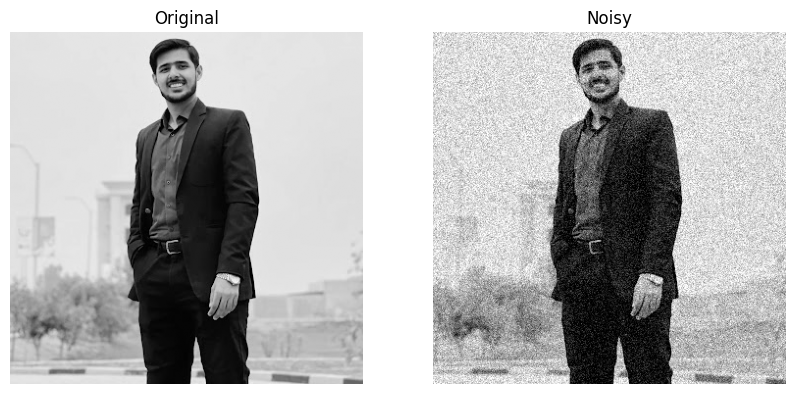

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("../assets/image.jpg", cv2.IMREAD_GRAYSCALE)
img_norm = img / 255.0

mean = 0
var = 0.01
sigma = np.sqrt(var)

gaussian_noise = np.random.normal(mean, sigma, img_norm.shape)
noisy_img = img_norm + gaussian_noise
noisy_img = np.clip(noisy_img, 0, 1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(img, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2); plt.title("Noisy"); plt.imshow(noisy_img, cmap="gray"); plt.axis("off")
plt.show()


## 2a. Manual Mean Filter Implementation


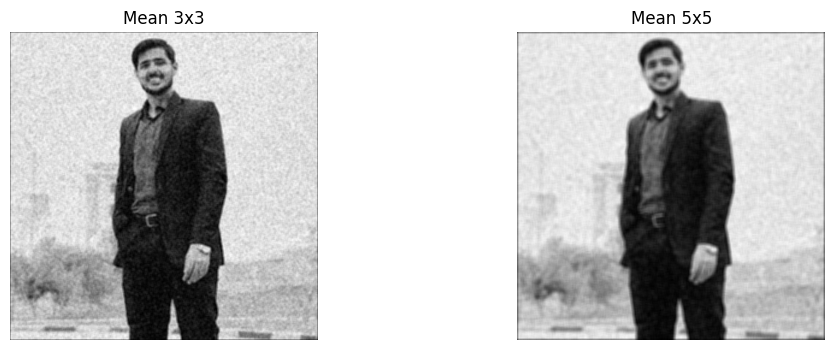

In [43]:
import numpy as np
import matplotlib.pyplot as plt

def mean_filter(img, ksize=3):
    pad = ksize // 2
    padded = np.pad(img, pad, mode="constant")
    filtered = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+ksize, j:j+ksize]
            filtered[i,j] = np.mean(region)
    return filtered

mean_3 = mean_filter(noisy_img, 3)
mean_5 = mean_filter(noisy_img, 5)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.title("Mean 3x3"); plt.imshow(mean_3, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2); plt.title("Mean 5x5"); plt.imshow(mean_5, cmap="gray"); plt.axis("off")
plt.show()


## 2b. Manual Guassian Filter Implementation

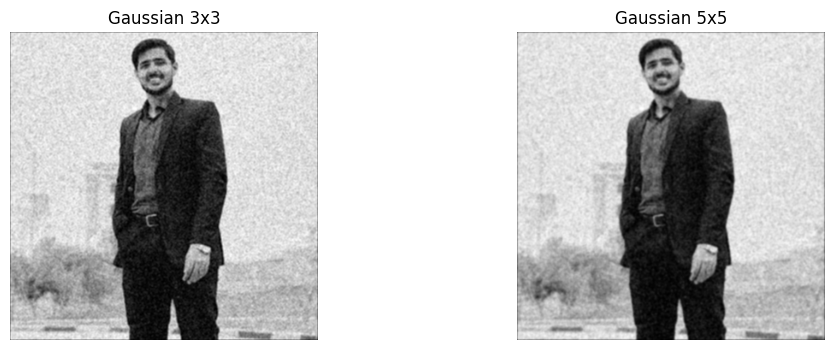

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_kernel(ksize=3, sigma=1.0):
    ax = np.linspace(-(ksize // 2), ksize // 2, ksize)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

def apply_filter(img, kernel):
    ksize = kernel.shape[0]
    pad = ksize // 2
    padded = np.pad(img, pad, mode="constant")
    filtered = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+ksize, j:j+ksize]
            filtered[i, j] = np.sum(region * kernel)
    return filtered

gauss3 = apply_filter(noisy_img, gaussian_kernel(3, 1.0))
gauss5 = apply_filter(noisy_img, gaussian_kernel(5, 1.0))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.title("Gaussian 3x3"); plt.imshow(gauss3, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2); plt.title("Gaussian 5x5"); plt.imshow(gauss5, cmap="gray"); plt.axis("off")
plt.show()


## 3. Which filter is better and why?

Gaussian filter is better because it gives more weight to center pixels, preserving edges while still removing noise.

Mean filter blurs edges more since it averages all pixels equally.

## 4. Why does a larger filter (5×5 vs 3×3) remove more noise but blur edges more?

A larger kernel considers more neighbors, smoothing stronger → more noise reduction.

But edges are also high-frequency features → they get blurred as well.

## 5. Why does Gaussian filtering preserve edges better than mean filtering?

Gaussian gives higher weight to center pixels → nearby pixels influence more.

Mean filter treats all neighbors equally → strong blurring of edges.

## 6. In which situations is mean filtering preferable?

When noise is very strong and random (e.g., salt-and-pepper), mean filtering can smooth aggressively.

It is also simpler and faster → good for real-time, low-power systems.

## 7. Why does Sobel operator use larger weights for center pixels (-2, 2) compared to corners (-1, 1)?

Center pixels represent the main intensity change direction.

Larger weights make the operator more sensitive to edges while reducing noise influence from far pixels.

# Question 5

## Manual Implementation of Sobel Filters

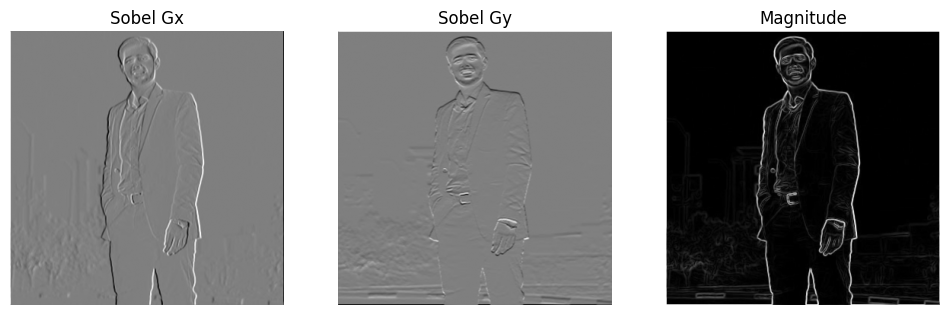

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("../assets/image.jpg", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32) / 255.0

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float32)

def apply_filter(img, kernel):
    k = kernel.shape[0]
    pad = k // 2
    padded = np.pad(img, pad, mode="constant")
    filtered = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+k, j:j+k]
            filtered[i,j] = np.sum(region * kernel)
    return filtered

Gx = apply_filter(img, sobel_x)
Gy = apply_filter(img, sobel_y)

magnitude = np.sqrt(Gx**2 + Gy**2)
magnitude = (magnitude / magnitude.max()) * 255
direction = np.arctan2(Gy, Gx)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.title("Sobel Gx"); plt.imshow(Gx, cmap="gray"); plt.axis("off")
plt.subplot(1,3,2); plt.title("Sobel Gy"); plt.imshow(Gy, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("Magnitude"); plt.imshow(magnitude, cmap="gray"); plt.axis("off")
plt.show()


## Edge Magnitude and Direction

Magnitude: Shows how strong an edge is at each pixel.

Direction: Shows the orientation of the edge (horizontal, vertical, diagonal).

## 3. Comparison with Finite Difference (Q3)

### Finite Difference

Uses simple subtraction between neighboring pixels.

Very sensitive to noise.

Detects edges but often produces rough/thin edges.

### Sobel Operator

Uses weighted convolution (more weight on closer pixels, e.g., -2,2).

Reduces effect of noise.

Produces smoother and more continuous edges.

Better edge localization than raw finite difference.


## Observations

Sobel edges look cleaner and more defined compared to finite difference.

Sobel is less sensitive to random noise because of averaging effect.

Finite difference detects more edges (including false ones), while Sobel emphasizes stronger, meaningful edges.

# Question 6 (BONUS)

## 1. Gaussian Smoothing

We first reduce noise so that false edges don’t appear.

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("../assets/image.jpg", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32) / 255.0

def gaussian_kernel(size=5, sigma=1):
    ax = np.linspace(-(size//2), size//2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    return kernel / np.sum(kernel)

def apply_filter(img, kernel):
    k = kernel.shape[0]
    pad = k // 2
    padded = np.pad(img, pad, mode="constant")
    filtered = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+k, j:j+k]
            filtered[i,j] = np.sum(region * kernel)
    return filtered

blurred = apply_filter(img, gaussian_kernel(5,1))


## 2. Gradient Magnitude & Direction (Sobel)

In [47]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float32)

Gx = apply_filter(blurred, sobel_x)
Gy = apply_filter(blurred, sobel_y)

magnitude = np.sqrt(Gx**2 + Gy**2)
magnitude = (magnitude / magnitude.max()) * 255

direction = np.arctan2(Gy, Gx)

print("Magnitude: ", magnitude)
print("Direction: ", direction)


Magnitude:  [[207.51724  229.23141  246.74342  ... 246.9117   229.57094  207.94556 ]
 [229.2024   100.26142   78.89144  ...  79.30816  100.397316 229.73518 ]
 [246.58763   78.90898   19.970589 ...  20.256445  78.871925 247.44139 ]
 ...
 [245.99887   79.3019    22.231853 ...  44.951546  57.36704  134.16092 ]
 [227.74579  100.78699   80.30515  ...  51.268208  56.893047 112.872856]
 [205.62941  227.356    244.77325  ... 115.90802  108.30136   97.898285]]
Direction:  [[ 0.7853982   1.3670987   1.5360811  ...  1.6041421   1.7730732
   2.3556612 ]
 [ 0.20348223  0.78488576  1.4045941  ...  1.7298671   2.3509183
   2.937085  ]
 [ 0.03346867  0.16091853  0.77138007 ...  2.3191466   2.9699974
   3.1062622 ]
 ...
 [-0.04040891 -0.19366106 -0.8609077  ... -1.6877263  -2.36337
  -2.9476318 ]
 [-0.20814428 -0.79637015 -1.4077839  ... -1.652579   -2.186875
  -2.8723218 ]
 [-0.7863008  -1.3674185  -1.5363108  ... -1.5934722  -1.7591556
  -2.3461523 ]]


## 3. Non-Maximum Suppression

Thins edges → keep only local maxima along gradient direction.

In [48]:
def non_maximum_suppression(mag, dir):
    Z = np.zeros_like(mag)
    angle = dir * 180. / np.pi
    angle[angle < 0] += 180
    for i in range(1, mag.shape[0]-1):
        for j in range(1, mag.shape[1]-1):
            q = 255
            r = 255
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = mag[i, j+1]
                r = mag[i, j-1]
            elif (22.5 <= angle[i,j] < 67.5):
                q = mag[i+1, j-1]
                r = mag[i-1, j+1]
            elif (67.5 <= angle[i,j] < 112.5):
                q = mag[i+1, j]
                r = mag[i-1, j]
            elif (112.5 <= angle[i,j] < 157.5):
                q = mag[i-1, j-1]
                r = mag[i+1, j+1]
            if (mag[i,j] >= q) and (mag[i,j] >= r):
                Z[i,j] = mag[i,j]
            else:
                Z[i,j] = 0
    return Z

nms = non_maximum_suppression(magnitude, direction)


## 4. Double Thresholding + Hysteresis

Classify pixels as strong edges, weak edges, or non-edges.

In [49]:
def threshold(img, lowRatio=0.05, highRatio=0.15):
    high = img.max() * highRatio
    low = high * lowRatio
    res = np.zeros_like(img)
    strong = 255
    weak = 75
    strong_i, strong_j = np.where(img >= high)
    weak_i, weak_j = np.where((img <= high) & (img >= low))
    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak
    return res, weak, strong

def hysteresis(img, weak, strong=255):
    for i in range(1, img.shape[0]-1):
        for j in range(1, img.shape[1]-1):
            if img[i,j] == weak:
                if ((img[i+1, j-1] == strong) or (img[i+1, j] == strong) or 
                    (img[i+1, j+1] == strong) or (img[i, j-1] == strong) or 
                    (img[i, j+1] == strong) or (img[i-1, j-1] == strong) or 
                    (img[i-1, j] == strong) or (img[i-1, j+1] == strong)):
                    img[i,j] = strong
                else:
                    img[i,j] = 0
    return img

dt, weak, strong = threshold(nms)
canny_manual = hysteresis(dt, weak, strong)


## 5. Compare with OpenCV’s Canny

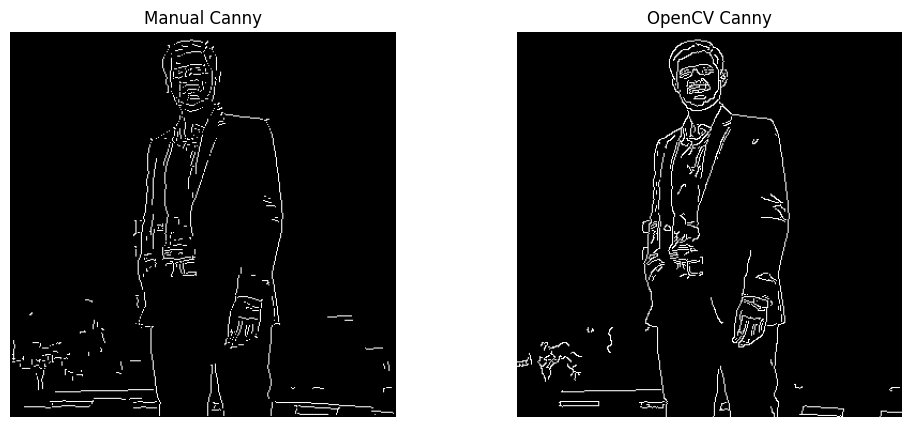

In [50]:
canny_cv = cv2.Canny((img*255).astype(np.uint8), 100, 200)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Manual Canny")
plt.imshow(canny_manual, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("OpenCV Canny")
plt.imshow(canny_cv, cmap="gray")
plt.axis("off")

plt.show()


### Why do we need two thresholds in Canny instead of one?

One threshold → misses weak edges or includes too much noise.

Two thresholds →

High threshold: keeps only strong edges.

Low threshold: allows weak edges to be kept only if they connect to strong edges.

This ensures balance between noise removal and edge connectivity.

### Why does non-maximum suppression thin edges instead of completely removing them?

It suppresses pixels that are not the local maximum along gradient direction.

Keeps only the strongest response → edges become 1-pixel thin, but not deleted entirely.

### How does hysteresis help in connecting weak edges with strong edges?

Some weak edges are real but faint (like low contrast).

Hysteresis keeps them if they are connected to strong edges.

Prevents breaking of continuous edges and ensures edge connectivity.